In [1]:
from langgraph.graph import StateGraph,END,START 
from typing import TypedDict

In [2]:
class BMIState(TypedDict):
    hight:int 
    weight:int 
    bmi:float 
    category:str

In [7]:
def calculate_bmi(state:BMIState)->BMIState:
    bmi = state['weight']/(state['hight']**2)

    return {"bmi":bmi} 



def calculate_cat(state:BMIState)->BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    #return state
    return {'category':state['category']}


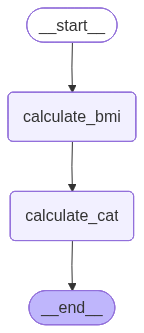

In [8]:
graph = StateGraph(BMIState)

graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('calculate_cat',calculate_cat)

graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','calculate_cat')
graph.add_edge('calculate_cat',END) 

workflow = graph.compile()
workflow

In [9]:
intial_state = {'weight':56.5, 'hight':1.65}

final_state = workflow.invoke(intial_state)

print(final_state)


{'hight': 1.65, 'weight': 56.5, 'bmi': 20.75298438934803, 'category': 'Normal'}


# Simple Model

In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
model = ChatOpenAI


In [10]:
from langgraph.graph import StateGraph,START,END 
from typing import TypedDict

In [ ]:
class question_answer(TypedDict):
    question:str 
    answer:str 
    Topic:str


In [ ]:
def question(state:question_answer)->question_answer:
    question = state['question']
    topic = state['Topic']

    prompt = f"Read this topic {topic} and answer the following question {question}"

    answer = model.invoke(prompt).content

    return {'answer':answer}

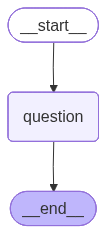

In [14]:
graph = StateGraph(question_answer)
graph.add_node('question',question)
graph.add_edge(START,'question')
graph.add_edge('question',END)

graph.compile()

# Simple Chain

In [15]:
from langgraph.graph import StateGraph ,START ,END 
from typing import TypedDict 

In [18]:
class BlogState(TypedDict):
    tittle:str 
    outline:str 
    content:str 


In [ ]:
def create_outline(state:BlogState)->BlogState:
    tittle = state['tittle']
    prompt = f"Write a details outline on this topic{tittle}"

    outline = model.invoke(prompt).content 
    return {'outline':outline}

def create_content(state:BlogState)->BlogState:
    tittle = state['tittle']
    outline = state['outline']
    prompt = f"write a blog in tittle{tittle} and the following outline \n\n{outline}"

    content = model.invoke(prompt).content 

    return {'content':content}

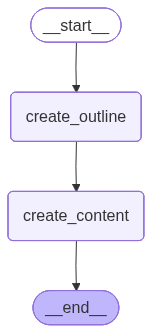

In [21]:
workflow = StateGraph(BlogState)

workflow.add_node('create_outline',create_outline)
workflow.add_node('create_content',create_content)

workflow.add_edge(START,'create_outline')
workflow.add_edge('create_outline','create_content')
workflow.add_edge('create_content',END)

workflow.compile()